# Import Library

In [1]:
import numpy as np
import matplotlib as plt
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup
import openpyxl

# Scrapping Website CoinMarketCap

In [1]:
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup


def scrape():
    url = 'https://coinmarketcap.com/gainers-losers/'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) ...'
    }
    try:
        response = requests.get(url, headers=headers)
    except Exception as e:
        print(f"Koneksi gagal: {e}")
        return [], []

    if response.status_code != 200:
        print(f'Error: {response.status_code}')
        return [], []

    soup = BeautifulSoup(response.text, 'html.parser')
    tables = soup.findAll('table', class_='cmc-table')

    if len(tables) < 2:
        print("Tabel tidak ditemukan (kemungkinan konten di-render oleh JS).")
        return [], []

    def parse_table(target_table):
        data = []
        rows = target_table.findAll('tr')[1:]
        for row in rows:
            cols = row.findAll('td')
            if len(cols) >= 5:  # ✅ minimal 5 kolom
                data.append({
                    "Name": cols[1].text.strip(),
                    "Price": cols[2].text.strip(),
                    "24h Change": cols[3].text.strip(),
                    "Volume(24h)": cols[4].text.strip()
                })
        return data

    return parse_table(tables[0]), parse_table(tables[1])

gainers, losers = scrape()

if gainers or losers:
    df_gainers = pd.DataFrame(gainers)
    df_gainers.to_excel("gainers.xlsx", index=False)  # ✅ index=False

    df_losers = pd.DataFrame(losers)
    df_losers.to_excel("losers.xlsx", index=False)

C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\2900036570.py:25: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  tables = soup.findAll('table', class_='cmc-table')
C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\2900036570.py:33: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = target_table.findAll('tr')[1:]
C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\2900036570.py:35: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cols = row.findAll('td')


# DataFrame Gainners Coin

In [2]:
gainners = pd.read_excel("gainers.xlsx")
dataframe_gainners = pd.DataFrame(gainners)
dataframe_gainners.head(10)

,Name,Price,24h Change,Volume(24h)
0,RaveDAO88RAVE,$1.88,254.63%,"$696,161,103"
1,Chiliz87CHZ,$0.04631,7.31%,"$178,110,586"
2,币安人生84币安人生,$0.4847,6.93%,"$99,938,507"
3,Monad97MON,$0.03244,6.83%,"$81,929,277"
4,Toncoin29TON,$1.38,6.70%,"$183,687,570"
5,Stellar16XLM,$0.1795,6.33%,"$132,118,027"
6,Pudgy Penguins86PENGU,$0.007645,5.79%,"$138,363,380"
7,LayerZero79ZRO,$1.65,5.57%,"$106,946,583"
8,JUST70JST,$0.07724,5.38%,"$28,666,633"
9,Mantle37MNT,$0.6434,4.85%,"$1,311,857,853"


# DataFrame Lossers Coin

In [4]:
loserss = pd.read_excel("losers.xlsx")
dataframe_losers = pd.DataFrame(loserss)
dataframe_losers.head(10)

,Name,Price,24h Change,Volume(24h)
0,Ethena56ENA,$0.1115,4.16%,"$99,396,444"
1,DeXe52DEXE,$14.35,3.04%,"$30,964,889"
2,Pi42PI,$0.1701,1.22%,"$22,966,977"
3,Uniswap38UNI,$3.26,0.67%,"$220,583,101"
4,Canton17CC,$0.1507,0.44%,"$26,167,425"
5,TRON8TRX,$0.3291,0.41%,"$730,877,619"
6,ether.fi98ETHFI,$0.4562,0.16%,"$25,400,736"
7,Jupiter75JUP,$0.1699,0.13%,"$19,985,605"
8,PAX Gold34PAXG,"$4,776.42",0.03%,"$231,573,504"


# Check Missing Value Gainners

In [5]:
df_gainers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Check Missing Value Lossers

In [6]:
df_losers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Data Cleaning Gainners & Lossers

In [7]:
for df in [df_gainers, df_losers]:
    df['Price'] = df['Price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
    df['24h Change'] = df['24h Change'].str.replace('%', '', regex=False).astype(float)
    df['Volume(24h)'] = df['Volume(24h)'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)

df_gainers.head()

,Name,Price,24h Change,Volume(24h)
0,RaveDAO88RAVE,1.88000,254.63,696161103.0
1,Chiliz87CHZ,0.04631,7.31,178110586.0
2,币安人生84币安人生,0.48470,6.93,99938507.0
3,Monad97MON,0.03244,6.83,81929277.0
4,Toncoin29TON,1.38000,6.70,183687570.0


# Check Outlier Gainners

In [8]:
Q1 = df_gainers['Price'].quantile(0.25)
Q3 = df_gainers['Price'].quantile(0.75)
IQR = Q3 - Q1  

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_iqr = df_gainers[
    (df_gainers['Price'] < lower) | (df_gainers['Price'] > upper)
]

print('Jumlah outlier dari gainers: ', len(outlier_iqr))

Jumlah outlier dari gainers:  6


# Check Outlier Lossers

In [10]:
Q1 = df_losers['Price'].quantile(0.25)
Q3 = df_losers['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

qutlier_iqr = df_losers[
    (df_losers['Price'] < lower) | (df_losers['Price'] > upper)
]

print('Jumlah outlier dari losers: ', len(qutlier_iqr))

Jumlah outlier dari losers:  2


# Handling Outlier Gainners

In [11]:
data_iqr_clean_gainners = df_gainers[
    (df_gainers['Price'] >= lower) & (df_gainers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_gainners))

Jumlah data yang bersih:  26


# EDA Gainners

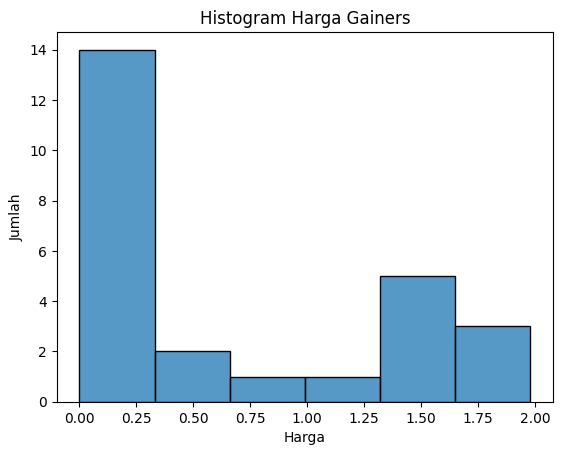

In [12]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_gainners[data_iqr_clean_gainners['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# Handling Outlier Lossers

In [13]:
data_iqr_clean_lossers = df_losers[
    (df_losers['Price'] >= lower) & (df_losers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_lossers))

Jumlah data yang bersih:  7


# EDA lossers

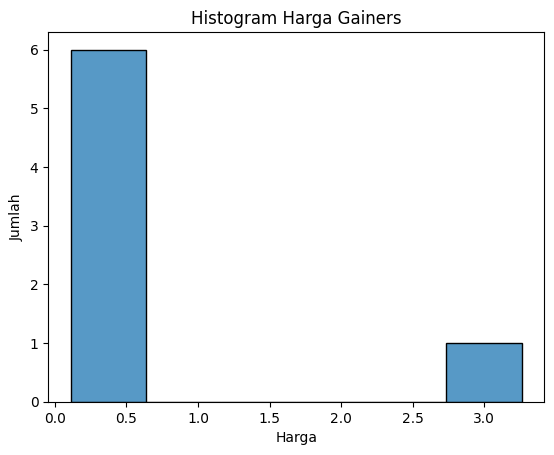

In [14]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_lossers[data_iqr_clean_lossers['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# EDA Pie Chart (Perubahan Koin Gainners dalam 24 jam terakhir)

d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

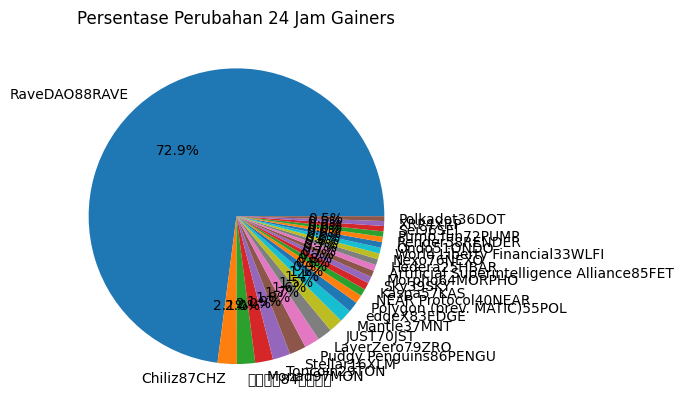

In [15]:
plt.Figure(figsize=(10, 6))
plt.pie(data_iqr_clean_gainners['24h Change'], labels=data_iqr_clean_gainners['Name'], autopct='%1.1f%%')
plt.title('Persentase Perubahan 24 Jam Gainers')
plt.show()

# EDA Pie Chart (Perubahan Koin Lossers dalam 24 jam terakhir)

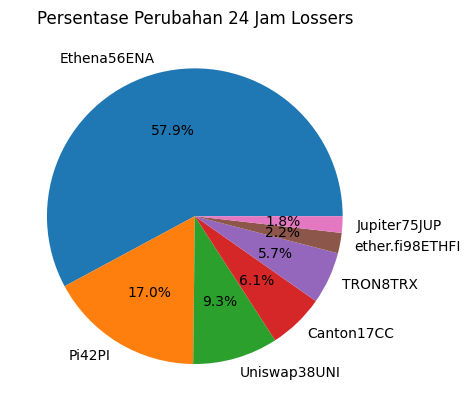

In [16]:
plt.Figure(figsize=(10, 6))
plt.pie(data_iqr_clean_lossers['24h Change'], labels=data_iqr_clean_lossers['Name'], autopct='%1.1f%%')
plt.title('Persentase Perubahan 24 Jam Lossers')
plt.show()

# Comparation Gonners and Lossers 

C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\3770351052.py:18: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\3770351052.py:18: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\3770351052.py:18: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_18104\3770351052.py:18: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


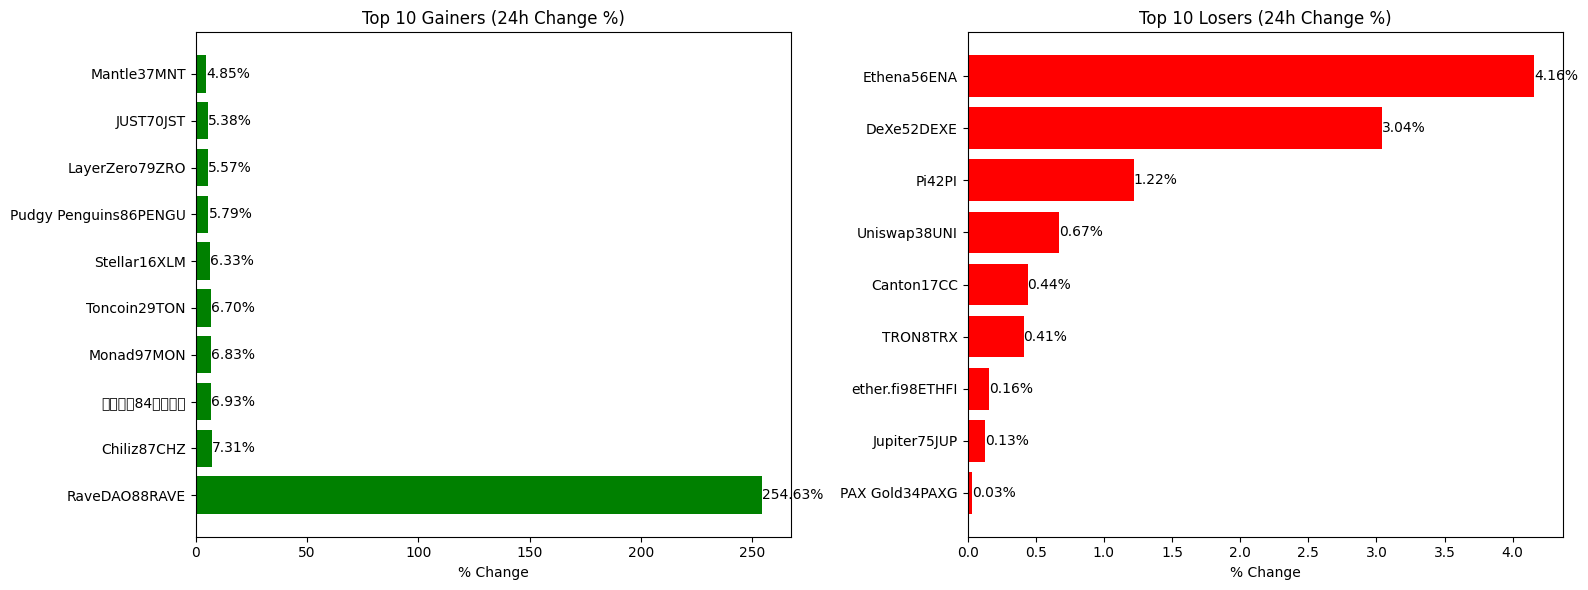

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_gainers = df_gainers.nlargest(10, '24h Change')
axes[0].barh(top_gainers['Name'], top_gainers['24h Change'], color='green')
axes[0].set_title('Top 10 Gainers (24h Change %)')
axes[0].set_xlabel('% Change')

top_losers = df_losers.nsmallest(10, '24h Change')
axes[1].barh(top_losers['Name'], top_losers['24h Change'], color='red')
axes[1].set_title('Top 10 Losers (24h Change %)')
axes[1].set_xlabel('% Change')

for i in top_gainers,top_losers:
     for index, value in enumerate(i['24h Change']):
        axes[0 if i is top_gainers else 1].text(value, index, f'{value:.2f}%', va='center')
        

plt.tight_layout()
plt.show()

# EDA Top 5 Gainners & Lossers by Volume

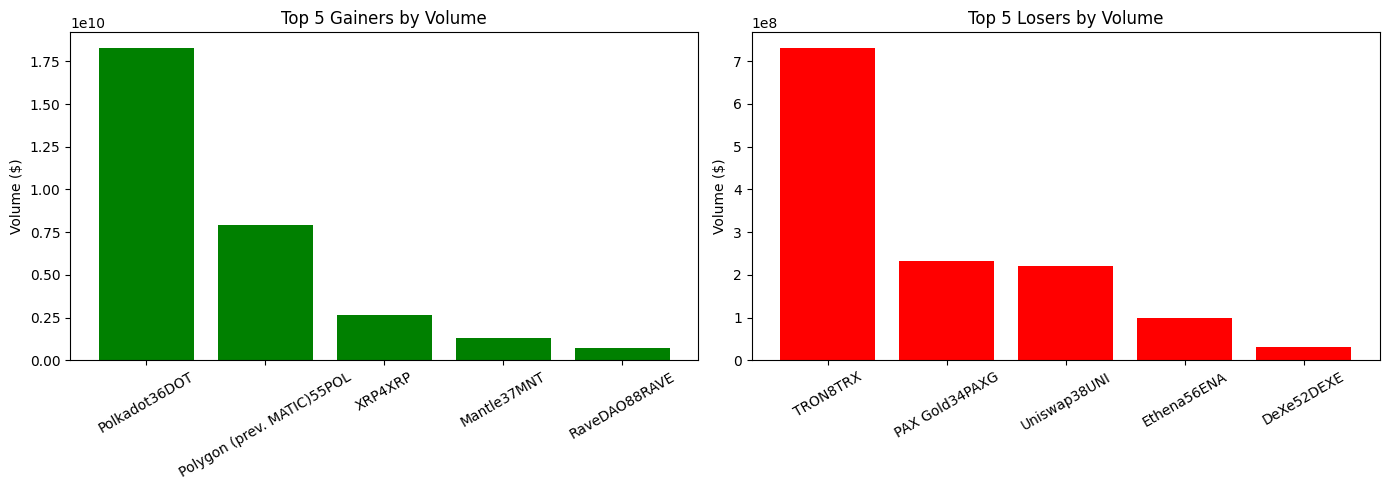

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [df_gainers, df_losers],
    ['Top 5 Gainers by Volume', 'Top 5 Losers by Volume'],
    ['green', 'red']
):
    top = df.nlargest(5, 'Volume(24h)')
    ax.bar(top['Name'], top['Volume(24h)'], color=color)
    ax.set_title(title)
    ax.set_ylabel('Volume ($)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()